# Análise Exploratória de Dados (EDA)

O primeiro passo em qualquer projeto de aprendizado de máquina é compreender os dados.

Neste notebook, iremos:

* Inspecionar a estrutura do conjunto de dados
* Explorar a variável alvo
* Identificar relações entre os atributos e o preço de venda
* Investigar valores ausentes
* Destacar possíveis oportunidades de engenharia de atributos

## Importação das bibliotecas

Primeiro, importamos as bibliotecas que serão utilizadas ao longo da análise.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

## Carregamento dos dados

A competição fornece conjuntos de dados separados para treinamento e teste. O conjunto de treinamento contém a variável alvo (`SalePrice`), enquanto o conjunto de teste contém apenas as variáveis preditoras.

Nesta etapa, carregamos ambos os conjuntos de dados, inspecionamos suas dimensões, verificamos a existência de linhas duplicadas, conferimos os nomes das colunas e realizamos uma inspeção inicial de sua estrutura.


In [2]:
df_test = pd.read_csv("../data/raw/test.csv")
df_train = pd.read_csv("../data/raw/train.csv")

print(
f"""
--------------------
Train set:

{df_train.shape[0]} rows
{df_train.duplicated().sum()} duplicated rows
{df_train.shape[1]} columns
--------------------
Test set:

{df_test.shape[0]} rows
{df_test.duplicated().sum()} duplicated rows
{df_test.shape[1]} columns
--------------------
Columns train/test:
{[column for column in df_train.columns if column in df_test.columns]}

Target variable (only in test):
{[column for column in df_train.columns if column not in df_test.columns]}
--------------------
"""
)


--------------------
Train set:

1460 rows
0 duplicated rows
81 columns
--------------------
Test set:

1459 rows
0 duplicated rows
80 columns
--------------------
Columns train/test:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrB

In [3]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


## Compreendendo a variável alvo

Com exceção da coluna `SalePrice`, que está ausente no conjunto de dados `df_test`, ambos os conjuntos possuem exatamente as mesmas variáveis. O preço de venda é, naturalmente, nossa variável alvo, isto é, a quantidade que desejamos prever a partir das demais características dos imóveis.

Como este é um problema de regressão, a variável alvo merece atenção especial. Vamos começar examinando a distribuição dos preços de venda dos imóveis.


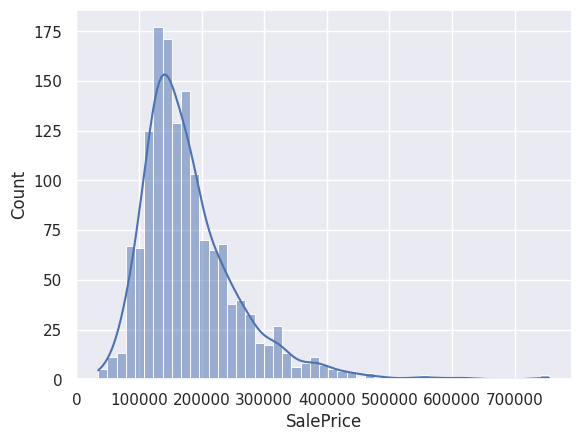

In [5]:
# Histogram
sns.histplot(df_train.get("SalePrice"), kde=True)
plt.show()

Como observado no histograma acima, a variável alvo `SalePrice` apresenta uma distribuição assimétrica à direita (*right-skewed*). Nesses casos, é comum aplicar uma transformação logarítmica para reduzir a assimetria da distribuição. Após essa transformação, a variável passa a apresentar uma distribuição mais próxima da normal.


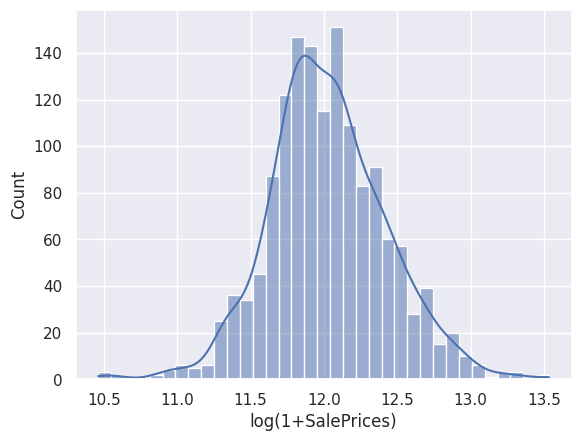

In [6]:
# Histogram log
sns.histplot(np.log1p(df_train.get("SalePrice")), kde=True)
plt.xlabel("log(1+SalePrices)")
plt.show()

It is also useful to check for outliers in the house prices.

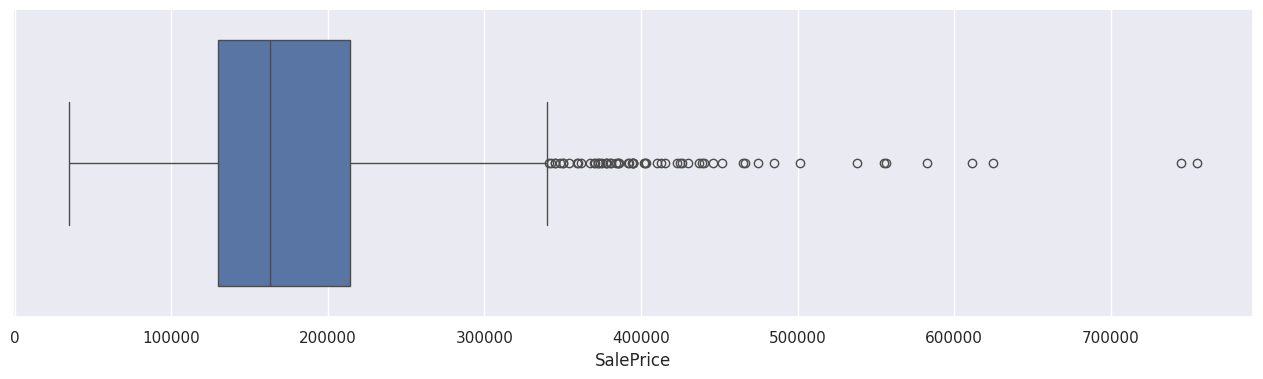

In [7]:
# Boxplot
plt.figure(figsize=(16, 4))
sns.boxplot(df_train["SalePrice"], orient="h")
plt.xlabel("SalePrice")
plt.show()

Também é possível observar a presença de valores atípicos (*outliers*), que serão tratados em uma etapa posterior. Por enquanto, vamos direcionar nossa atenção às demais variáveis do conjunto de dados.


## Mapping the features

The file [`data_description.txt`](../data/raw/data_description.txt) documents all variables in the dataset. In this section, we extract those descriptions and combine them with information derived from `df_train` and `df_test` (such as data type: numerical or categorical) into a single summary dataframe.

We also introduce a `Category` field: it is set to `"original"` for all features that come directly from the Kaggle dataset, and later will assume other values for features created during the feature engineering stage.

In [8]:
# All features minus the tareget
features = [column for column in df_test.columns if column not in ("Id", "SalePrice", "IsTrainSet")]

# feature description dataframe
df_features = pd.DataFrame({
    "Name": features,
    "Type": ["numerical" if pd.api.types.is_numeric_dtype(df_test[column]) else "categorical" for column in features],
    "Category":["original"]*len(features),
    "Source":features,
})

# Get descriptions from data_description.txt
with open("../data/raw/data_description.txt", "r", encoding="utf-8") as f:
    lines = f.readlines()
feature_to_description = {}
for feature in features:
    desc = None
    # Scan lines looking for a line that starts with "FeatureName:"
    prefix = f"{feature}:"
    for line in lines:
        line = line.strip()
        if line.startswith(prefix):
            # Take everything after "FeatureName:" as the description
            desc = line[len(prefix):].strip()
            break
    feature_to_description[feature] = desc

df_features["Description"] = df_features["Name"].map(feature_to_description)

df_features

,Name,Type,Category,Source,Description
0,MSSubClass,numerical,original,MSSubClass,Identifies the type of dwelling involved in th...
1,MSZoning,categorical,original,MSZoning,Identifies the general zoning classification o...
2,LotFrontage,numerical,original,LotFrontage,Linear feet of street connected to property
3,LotArea,numerical,original,LotArea,Lot size in square feet
4,Street,categorical,original,Street,Type of road access to property
...,...,...,...,...,...
74,MiscVal,numerical,original,MiscVal,$Value of miscellaneous feature
75,MoSold,numerical,original,MoSold,Month Sold (MM)
76,YrSold,numerical,original,YrSold,Year Sold (YYYY)
77,SaleType,categorical,original,SaleType,Type of sale


## Combinando os conjuntos de treinamento e teste

Muitas etapas de pré-processamento precisam ser aplicadas de forma consistente aos dois conjuntos de dados. Para facilitar a análise exploratória, é conveniente combinar temporariamente as variáveis preditoras dos conjuntos de treinamento e teste em um único *DataFrame*.

A variável alvo (`SalePrice`) é excluída dessa combinação, pois está disponível apenas no conjunto de treinamento.


In [9]:
# Train/Test split
df_train["IsTrainSet"] = True
df_test["IsTrainSet"] = False

df_full = pd.concat(
    [df_train, df_test],
    axis=0,
    ignore_index=True
)

print(
    f"""
    Full dataset ( train + test ):

    {df_full.shape[0]} rows
    {df_full.duplicated().sum()} duplicated rows
    {df_full.shape[1]} columns
    """
)

df_full


    Full dataset ( train + test ):

    2919 rows
    0 duplicated rows
    82 columns
    


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,IsTrainSet
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0,True
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0,True
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0,True
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0,True
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN,False
2915,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN,False
2916,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN,False
2917,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,NaN,MnPrv,Shed,700,7,2006,WD,Normal,NaN,False


Para começar a compreender melhor o conjunto de dados, podemos utilizar os métodos `info()` e `describe()` para inspecionar os tipos de dados, identificar valores ausentes e obter estatísticas descritivas, como média, mediana, valores mínimos e máximos, entre outras. Durante essa etapa de exploração, também é muito útil consultar o arquivo [`data_description.txt`](../data/raw/data_description.txt), disponível no diretório `data` deste repositório, que contém uma descrição detalhada de cada variável presente no conjunto de dados.


In [10]:
# Data types and Non-null counts
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallC

In [11]:
# Statistics
df_full.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,2919.000000,2919.000000,2433.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2896.000000,2918.000000,...,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,1460.000000
mean,1460.000000,57.137718,69.305795,10168.114080,6.089072,5.564577,1971.312778,1984.264474,102.201312,441.423235,...,93.709832,47.486811,23.098321,2.602261,16.062350,2.251799,50.825968,6.213087,2007.792737,180921.195890
std,842.787043,42.517628,23.344905,7886.996359,1.409947,1.113131,30.291442,20.894344,179.334253,455.610826,...,126.526589,67.575493,64.244246,25.188169,56.184365,35.663946,567.402211,2.714762,1.314964,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,730.500000,20.000000,59.000000,7478.000000,5.000000,5.000000,1953.500000,1965.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129975.000000
50%,1460.000000,50.000000,68.000000,9453.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,368.500000,...,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,2189.500000,70.000000,80.000000,11570.000000,7.000000,6.000000,2001.000000,2004.000000,164.000000,733.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,2919.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [12]:
# Numerical features from metadata
numerical_features = (
    df_features.loc[
        df_features["Type"] == "numerical",
        "Name"
    ]
    .tolist()
)

df_numerical = df_full[numerical_features]

# Categorical features from metadata
categorical_features = (
    df_features.loc[
        df_features["Type"] == "categorical",
        "Name"
    ]
    .tolist()
)

df_categorical = df_full[categorical_features]

## Histogramas

Assim como fizemos para a variável alvo, também podemos examinar a distribuição de todas as variáveis numéricas do conjunto de dados.


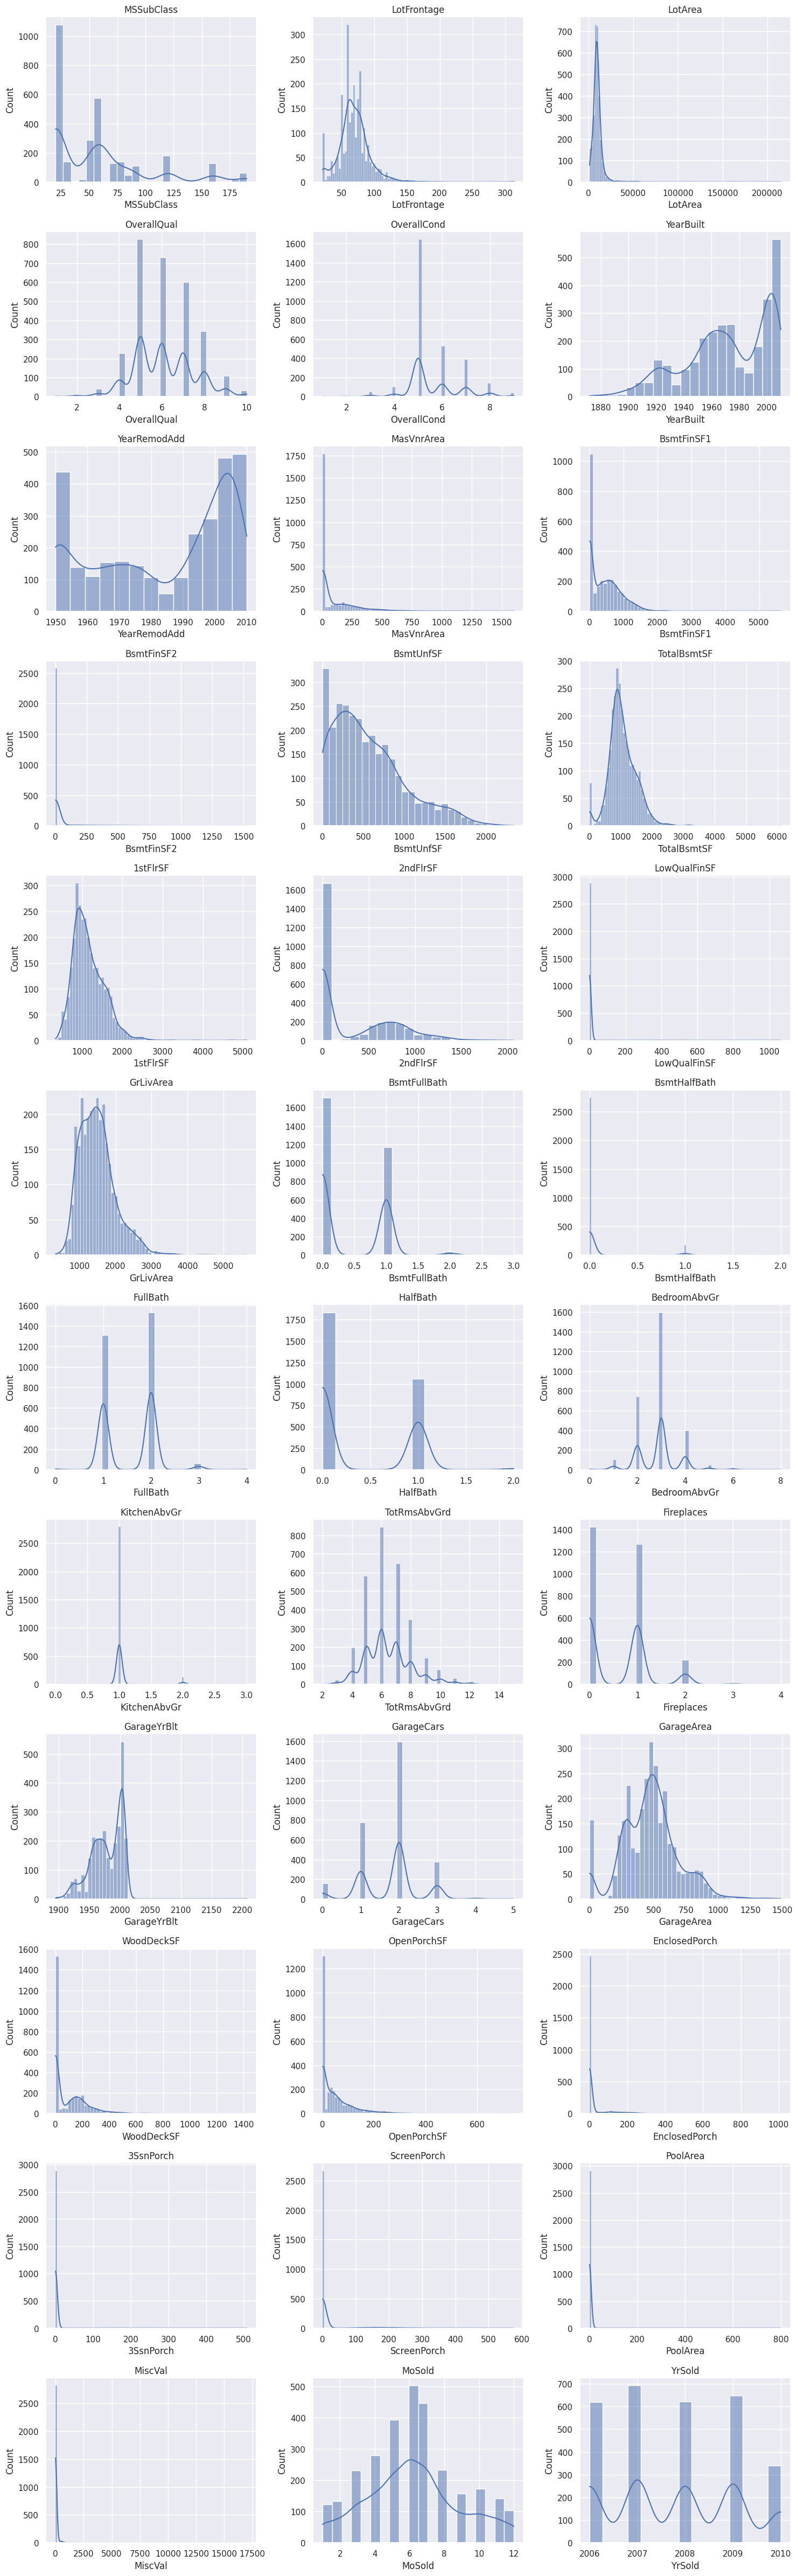

In [13]:
# Histograms for all numerical features
n_cols = 3  # adjust as needed
n_rows = int(np.ceil(len(numerical_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  # make it 1D for easy indexing

for i, col in enumerate(numerical_features):
    sns.histplot(df_numerical[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Podemos observar nos histogramas acima que diversas variáveis apresentam distribuições assimétricas à direita (*right-skewed*). Assim como ocorre com `SalePrice`, essas variáveis poderão se beneficiar de uma transformação logarítmica durante a etapa de modelagem.

No entanto, deixaremos a análise da assimetria (*skewness*) e a aplicação das transformações logarítmicas para o notebook de [engenharia de atributos](02_feature_engineering.ipynb).


## Valores Atípicos (*Outliers*)

Assim como fizemos para `SalePrice`, também podemos investigar a presença de valores atípicos (*outliers*) em todas as variáveis numéricas.


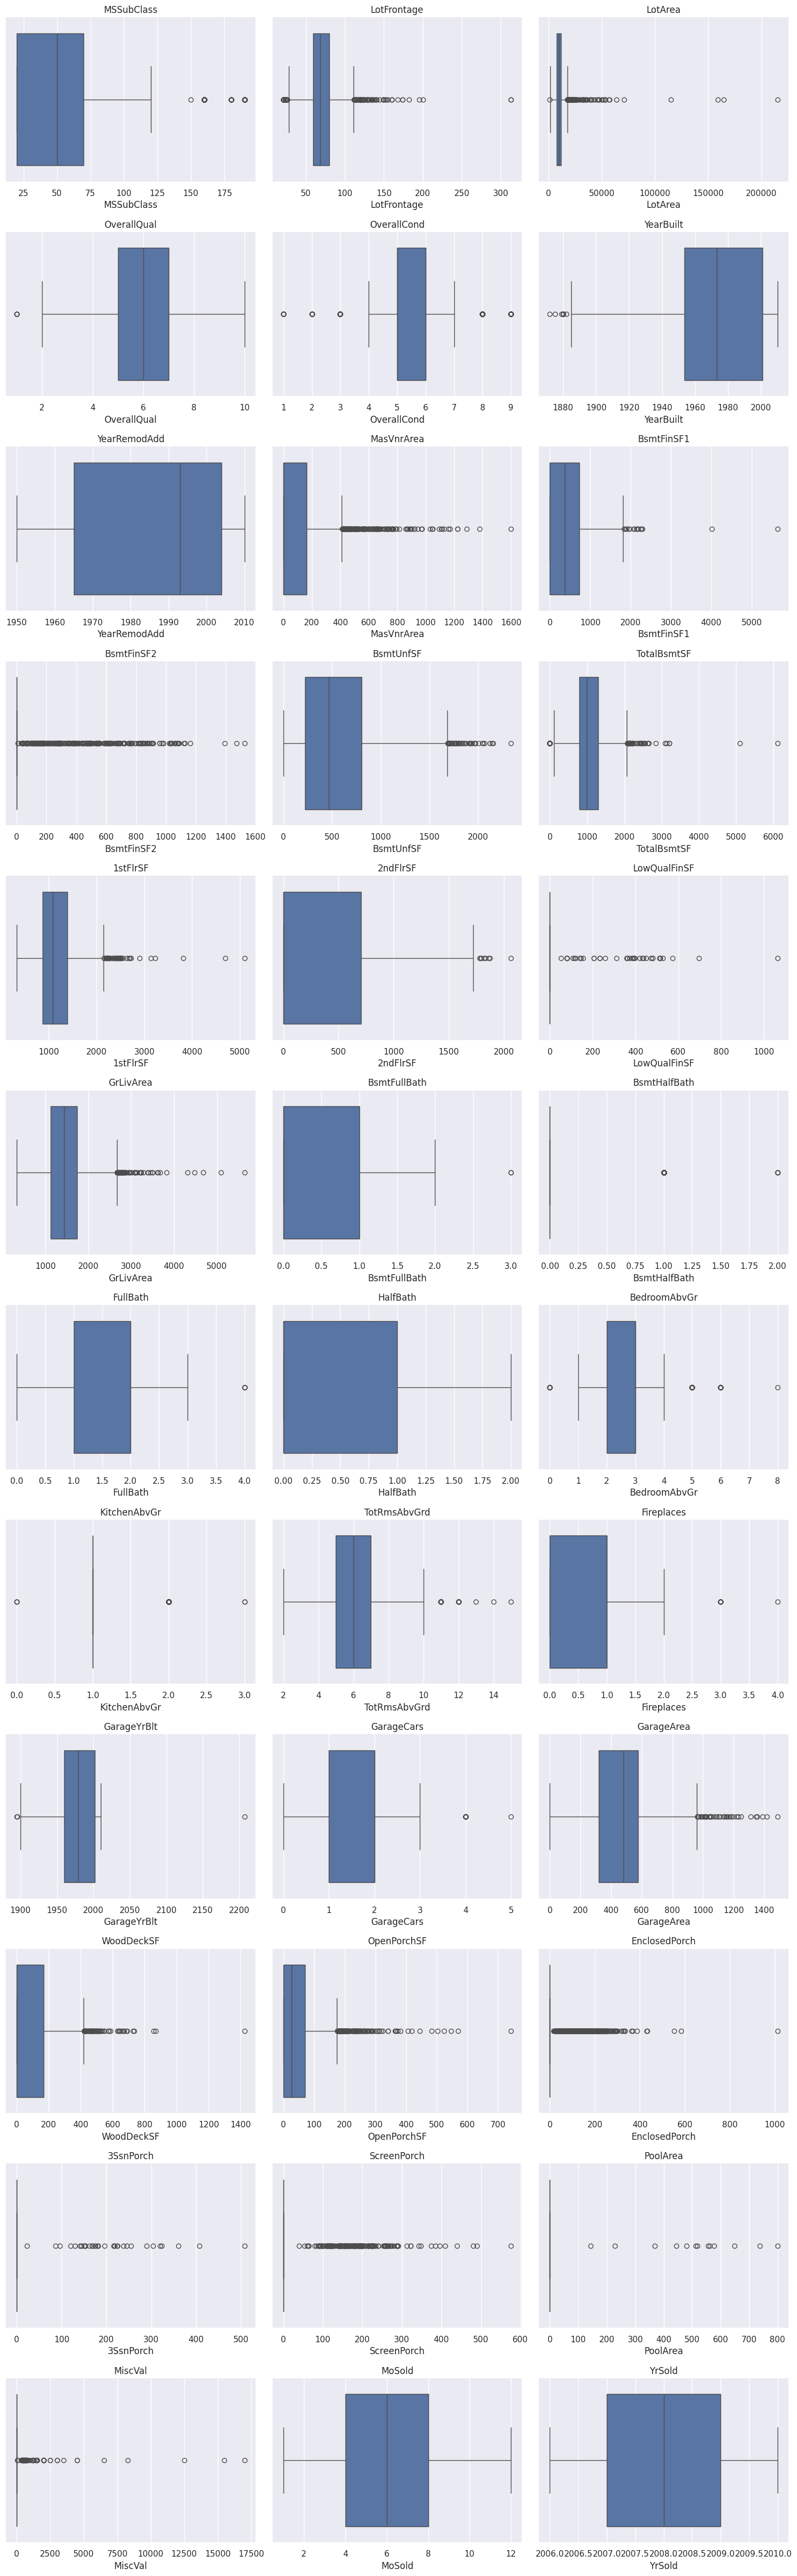

In [14]:
# Boxplots for all features
cols = df_numerical.columns
n_cols = 3  # adjust as needed
n_rows = int(np.ceil(len(numerical_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  # make it 1D for easy indexing

for i, col in enumerate(numerical_features):
    sns.boxplot(df_numerical[col], ax=axes[i], orient="h")
    axes[i].set_title(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

A partir dos gráficos acima, juntamente com o que observamos para `SalePrice`, fica evidente que o conjunto de dados contém valores atípicos (*outliers*). Não removeremos as linhas que contêm esses valores, pois isso pode resultar na perda de informações importantes. Em vez disso, os *outliers* serão tratados posteriormente, durante a etapa de modelagem.


## Valores Faltantes

Valores faltantes representam um dos principais desafios deste conjunto de dados. Antes de prosseguir com a análise, gosto de inspecionar visualmente a quantidade e a distribuição desses valores para compreender melhor o problema.


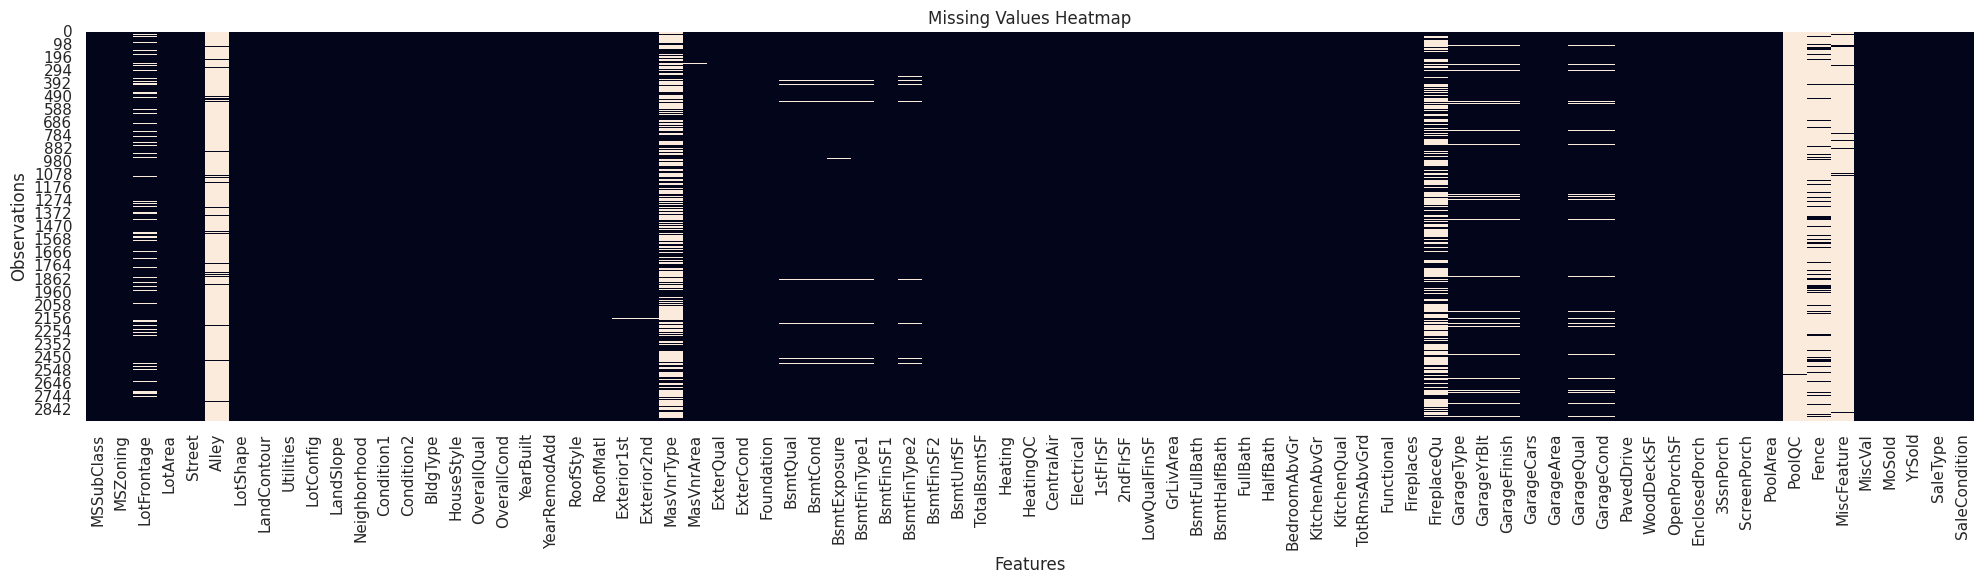

In [15]:
plt.figure(figsize=(20, 6))

sns.heatmap(
    df_full[features].isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")
plt.xlabel("Features")
plt.ylabel("Observations")

plt.tight_layout()
plt.show()

Antes de decidir como tratar os valores faltantes, precisamos compreender quais variáveis contêm observações ausentes, quantos valores estão faltando e se essas ausências podem, por si só, carregar alguma informação.

Analisaremos cada variável individualmente para determinar a estratégia de imputação mais adequada, utilizando o arquivo [`data_description.txt`](../data/raw/data_description.txt) como referência:

* **Para variáveis numéricas:** os valores faltantes serão preenchidos com `0` (quando este representar a ausência de um atributo), com a média ou com a mediana, dependendo da distribuição dos dados.
* **Para variáveis categóricas:** os valores faltantes serão preenchidos com `"None"` quando representarem a ausência de uma característica (por exemplo, ausência de piscina ou garagem), ou com a moda quando os dados estiverem realmente ausentes de forma aleatória.

Vamos começar listando todas as variáveis em ordem decrescente pela quantidade de valores faltantes.


In [16]:
# All features with missing values
df_missing = df_full[features].isnull().sum().sort_values(ascending=False)
df_missing = df_missing.loc[df_missing.values > 0]
df_missing

PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
FireplaceQu     1420
LotFrontage      486
GarageCond       159
GarageFinish     159
GarageYrBlt      159
GarageQual       159
GarageType       157
BsmtExposure      82
BsmtCond          82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrArea        23
MSZoning           4
BsmtHalfBath       2
Functional         2
BsmtFullBath       2
Utilities          2
Exterior1st        1
TotalBsmtSF        1
BsmtUnfSF          1
BsmtFinSF1         1
SaleType           1
KitchenQual        1
GarageCars         1
GarageArea         1
Electrical         1
Exterior2nd        1
BsmtFinSF2         1
dtype: int64

It will be usefull to separate the categorical from the numerical data.

### Categorical features



In [17]:
# Only categorical features
df_missing_categorical = df_full[categorical_features].isnull().sum().sort_values(ascending=False)
df_missing_categorical = df_missing_categorical.loc[df_missing_categorical.values > 0]
df_missing_categorical

PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
FireplaceQu     1420
GarageCond       159
GarageQual       159
GarageFinish     159
GarageType       157
BsmtCond          82
BsmtExposure      82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MSZoning           4
Utilities          2
Functional         2
Exterior2nd        1
Exterior1st        1
SaleType           1
KitchenQual        1
Electrical         1
dtype: int64

In [18]:
# Unique values and value counts
for column in df_missing_categorical.index:
    print("-"*30)
    print(df_full[column].value_counts(dropna=False))
print("-"*30)

------------------------------
PoolQC
NaN    2909
Ex        4
Gd        4
Fa        2
Name: count, dtype: int64
------------------------------
MiscFeature
NaN     2814
Shed      95
Gar2       5
Othr       4
TenC       1
Name: count, dtype: int64
------------------------------
Alley
NaN     2721
Grvl     120
Pave      78
Name: count, dtype: int64
------------------------------
Fence
NaN      2348
MnPrv     329
GdPrv     118
GdWo      112
MnWw       12
Name: count, dtype: int64
------------------------------
MasVnrType
NaN        1766
BrkFace     879
Stone       249
BrkCmn       25
Name: count, dtype: int64
------------------------------
FireplaceQu
NaN    1420
Gd      744
TA      592
Fa       74
Po       46
Ex       43
Name: count, dtype: int64
------------------------------
GarageCond
TA     2654
NaN     159
Fa       74
Gd       15
Po       14
Ex        3
Name: count, dtype: int64
------------------------------
GarageQual
TA     2604
NaN     159
Fa      124
Gd       24
Po        5
Ex  

Como podemos observar, quase todos os valores da variável `PoolQC` estão faltantes. Ao consultar o arquivo [`data_description.txt`](../data/raw/data_description.txt), verificamos que essa variável representa a **qualidade da piscina** (*Pool Quality*). Isso indica que a maioria dos imóveis não possui piscina. Nesse caso, o valor faltante não representa simplesmente ausência de informação, mas sim uma característica do imóvel.

O mesmo ocorre com todas as variáveis categóricas para as quais o arquivo [`data_description.txt`](../data/raw/data_description.txt) indica que `NA` significa `"None"` ou que o imóvel não possui determinado item. Para essas variáveis, substituímos os valores faltantes pela string `"None"`.

Algumas variáveis possuem apenas uma pequena quantidade de valores faltantes e apresentam uma categoria dominante. Por exemplo, a maior parte das observações em `SaleType` possui o valor `"WD"`. Para essas variáveis, os valores faltantes são substituídos pela moda. A moda é calculada utilizando apenas o conjunto de treinamento e posteriormente aplicada a ambos os conjuntos de dados, garantindo um procedimento de pré-processamento consistente e evitando *data leakage*.

Alguns exemplos:

* `Exterior1st`: revestimento externo da casa (*Exterior covering on house*). É razoável assumir que todas as casas possuem algum tipo de revestimento externo. Portanto, o único valor faltante é preenchido com a moda da variável, que corresponde a `"Vinyl Siding"`.

* `Exterior2nd`: revestimento externo da casa (quando existe mais de um material). Como é possível que uma casa não possua um segundo material de revestimento externo, o único valor faltante é preenchido com `"None"`.

In [19]:
# Fill with "None"
list_na_is_none = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu",
    "GarageCond",
    "GarageFinish",
    "GarageQual",
    "GarageType",
    "BsmtCond",
    "BsmtExposure",
    "BsmtQual",
    "BsmtFinType2",
    "BsmtFinType1",
    "Exterior2nd",
]
for column in list_na_is_none:
    df_full[column] = df_full[column].fillna("None")

# Fill with the mode
list_na_is_mode = [
    "MSZoning",
    "Functional",
    "Utilities",
    "KitchenQual",
    "SaleType",
    "Electrical",
    "Exterior1st",
]
for column in list_na_is_mode:
    fill_with_mode = df_full.loc[df_full["IsTrainSet"], column].mode()[0]
    df_full[column] = df_full[column].fillna(fill_with_mode)


### Numerical features

In [20]:
# Only numerical features
df_missing_numerical = df_full[numerical_features].isnull().sum().sort_values(ascending=False)
df_missing_numerical = df_missing_numerical.loc[df_missing_numerical.values > 0]
df_missing_numerical

LotFrontage     486
GarageYrBlt     159
MasVnrArea       23
BsmtFullBath      2
BsmtHalfBath      2
GarageCars        1
BsmtFinSF2        1
GarageArea        1
TotalBsmtSF       1
BsmtFinSF1        1
BsmtUnfSF         1
dtype: int64

In [21]:
# Unique values and value counts
for column in df_missing_numerical.index:
    print("-"*30)
    print(df_full[column].value_counts(dropna=False))
print("-"*30)

------------------------------
LotFrontage
NaN      486
60.0     276
80.0     137
70.0     133
50.0     117
        ... 
155.0      1
126.0      1
200.0      1
131.0      1
133.0      1
Name: count, Length: 129, dtype: int64
------------------------------
GarageYrBlt
NaN       159
2005.0    142
2006.0    115
2007.0    115
2004.0     99
         ... 
1896.0      1
1895.0      1
2207.0      1
1943.0      1
1919.0      1
Name: count, Length: 104, dtype: int64
------------------------------
MasVnrArea
0.0      1738
NaN        23
120.0      15
176.0      13
200.0      13
         ... 
355.0       1
405.0       1
327.0       1
257.0       1
382.0       1
Name: count, Length: 445, dtype: int64
------------------------------
BsmtFullBath
0.0    1705
1.0    1172
2.0      38
3.0       2
NaN       2
Name: count, dtype: int64
------------------------------
BsmtHalfBath
0.0    2742
1.0     171
2.0       4
NaN       2
Name: count, dtype: int64
------------------------------
GarageCars
2.0    1594
1.

A maioria das variáveis numéricas com valores faltantes descreve características opcionais dos imóveis, como porões, garagens ou revestimento de alvenaria. Nesses casos, um valor faltante geralmente indica a ausência da característica correspondente, tornando `0` uma substituição adequada e com significado real.

Duas variáveis merecem atenção especial: `LotFrontage` e `GarageYrBlt`. Para `LotFrontage`, um valor faltante não significa que o imóvel possui zero metros de frente para a rua. Da mesma forma, `GarageYrBlt` está faltante quando não existe garagem, e não porque o ano de construção da garagem seria zero. Portanto, estratégias de imputação mais sofisticadas poderiam ser justificadas para essas variáveis.

No entanto, a quantidade de valores faltantes é relativamente pequena em comparação ao tamanho do conjunto de dados, e muitas das variáveis afetadas naturalmente admitem o valor `0` como representação da ausência da característica. Para manter o pipeline de pré-processamento simples e consistente, substituiremos todos os valores faltantes numéricos restantes por `0`.


In [22]:
# Fill missing values with 0
for column in df_missing_numerical.index:
    df_full[column] = df_full[column].fillna(0)

A inspeção das contagens de valores também revelou um possível erro de entrada de dados. A variável `GarageYrBlt` contém o valor `2207`, que é claramente implausível considerando o contexto do conjunto de dados. Como esse ano difere de `2007` por apenas um dígito e todas as demais observações estão dentro de uma faixa realista de anos de construção, interpretamos esse valor como um erro de digitação e o substituímos por `2007`, que parece ser o valor pretendido mais provável.


In [23]:
df_full["GarageYrBlt"] = df_full["GarageYrBlt"].replace(2207, 2007)

## Variáveis numéricas e a variável alvo

Um dos principais objetivos da análise exploratória de dados é identificar quais variáveis parecem estar relacionadas com a variável alvo. Para variáveis numéricas, uma forma simples de investigar essas relações é por meio de gráficos de dispersão (*scatterplots*).

Os gráficos abaixo comparam cada variável numérica com `SalePrice`. Embora essas visualizações não forneçam uma medida quantitativa de associação, elas podem revelar tendências, valores atípicos (*outliers*), relações não lineares e outros padrões que podem ser úteis nas etapas seguintes de modelagem e engenharia de atributos.


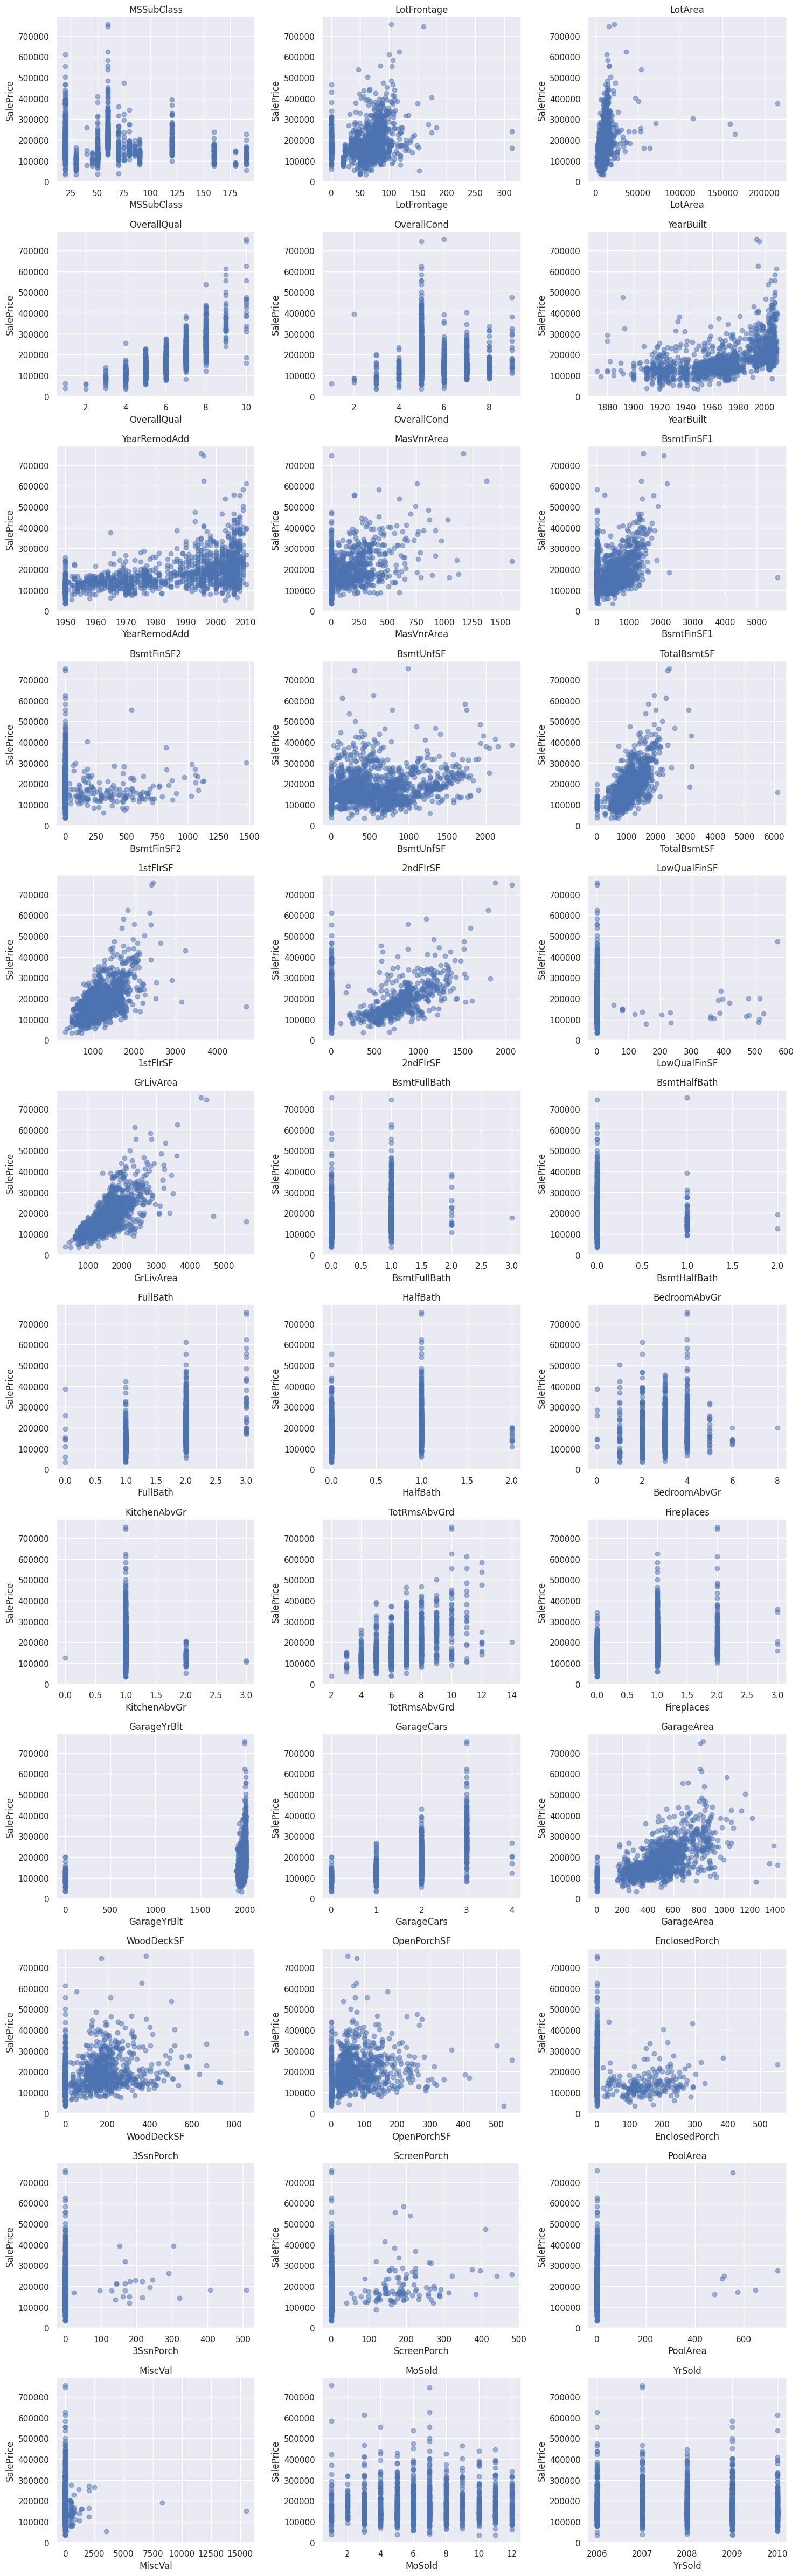

In [24]:
# Re-split train/test sets:
# Train set
df_train = df_full.loc[df_full["IsTrainSet"]]
X_train = df_train.drop(columns=["SalePrice", "IsTrainSet"])
y_train = df_full.loc[df_full["IsTrainSet"], "SalePrice"]
# Test set
X_test = df_full.loc[~df_full["IsTrainSet"]]

# Scatterplots for all features
cols = df_numerical.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows)
)

axes = axes.flatten()
for i, col in enumerate(cols):
    axes[i].scatter(
        X_train[col],
        y_train,
        alpha=0.5
    )

    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("SalePrice")

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Matriz de correlação

Os gráficos de dispersão fornecem uma visão qualitativa da relação entre cada variável individualmente e a variável alvo. Podemos complementar essa análise calculando a matriz de correlação entre as variáveis numéricas.

O coeficiente de correlação mede a intensidade e a direção de uma relação linear entre duas variáveis. Valores próximos de `1` indicam uma associação positiva forte, valores próximos de `-1` indicam uma associação negativa forte, enquanto valores próximos de `0` sugerem pouca ou nenhuma relação linear.

O mapa de calor (*heatmap*) abaixo destaca tanto as variáveis mais fortemente associadas a `SalePrice` quanto possíveis correlações entre variáveis preditoras, que podem indicar redundância ou problemas de multicolinearidade.


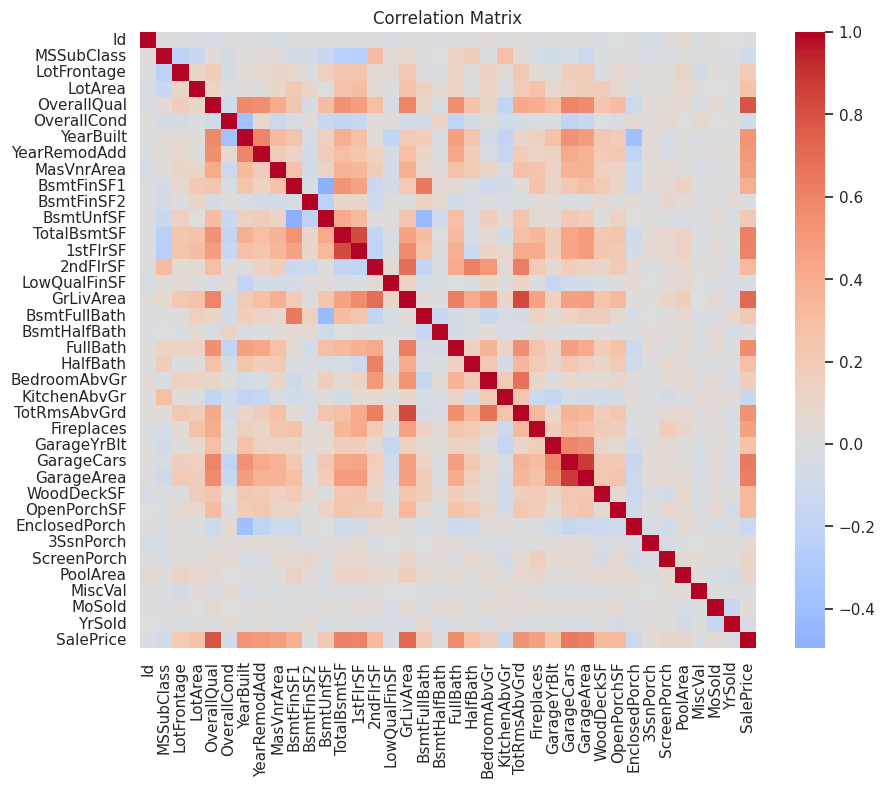

In [25]:
corr = df_train.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix")
plt.show()

Embora correlação não implique causalidade, ela fornece uma primeira indicação útil sobre quais variáveis podem ser mais informativas para a previsão dos preços dos imóveis. Variáveis que apresentam correlações positivas ou negativas fortes com `SalePrice` são candidatas naturais a serem incluídas nos modelos preditivos.

A análise de correlação também permite identificar relações entre as próprias variáveis preditoras. Variáveis altamente correlacionadas podem conter informações redundantes, o que é especialmente relevante em modelos lineares.

É importante destacar, entretanto, que esta análise é baseada apenas nas variáveis originais fornecidas pelo conjunto de dados. Na próxima etapa do projeto, criaremos diversas novas variáveis por meio da engenharia de atributos. Essas variáveis derivadas podem capturar relações que não são evidentes no conjunto original e, em alguns casos, apresentar correlações mais fortes com a variável alvo do que as variáveis originais das quais foram construídas.

Por esse motivo, revisitaremos a análise de correlação após a etapa de engenharia de atributos para avaliar como as novas variáveis se relacionam com `SalePrice`, verificar se elas fornecem informações preditivas adicionais e identificar casos em que múltiplas variáveis capturam informações semelhantes. Essa análise pode auxiliar na seleção de atributos e na redução de redundância, evitando a inclusão de várias variáveis altamente correlacionadas no mesmo modelo.


## Salvando o conjunto de dados processado

Neste estágio, todos os problemas de qualidade dos dados identificados e os valores faltantes foram tratados. Para evitar a repetição dessas etapas de pré-processamento nos próximos notebooks, salvamos o conjunto de dados resultante em disco.

O próximo notebook utilizará este conjunto de dados como base para realizar a engenharia de atributos e preparar os dados para os modelos de aprendizado de máquina.


In [26]:
# Save dataframes in parquet format to preserve data types
df_full.to_parquet(
    "../data/processed/01_data.parquet",
    index=False
)
df_features.to_parquet(
    "../data/processed/01_features.parquet",
    index=False
)

## Resumo

Neste notebook, exploramos o conjunto de dados House Prices e identificamos diversas características importantes que irão orientar as próximas etapas do projeto.

As principais conclusões foram:

* O conjunto de dados continha uma quantidade significativa de valores faltantes, muitos dos quais podiam ser interpretados como ausência de uma característica do imóvel e foram tratados dessa forma.
* Foram identificados e corrigidos alguns problemas de qualidade dos dados, incluindo um valor implausível na variável `GarageYrBlt`.
* A inspeção visual e a análise de correlação revelaram relações fortes entre `SalePrice` e variáveis como `OverallQual`, `GrLivArea`, atributos relacionados à garagem e outras medidas de tamanho e qualidade dos imóveis.
* Diversas variáveis preditoras apresentam forte correlação entre si, indicando a presença de redundância e possível multicolinearidade entre algumas variáveis numéricas.
* Tanto as variáveis numéricas quanto as categóricas parecem conter informações preditivas relevantes e provavelmente contribuirão para o desempenho dos modelos.

Neste estágio, temos uma compreensão sólida do conjunto de dados e dos principais fatores que influenciam os preços dos imóveis. No entanto, ainda são necessárias etapas adicionais de pré-processamento e engenharia de atributos antes do treinamento dos modelos de aprendizado de máquina. Em particular, será necessário codificar variáveis categóricas, transformar variáveis assimétricas e construir novos atributos que possam melhorar o desempenho preditivo.

No [próximo notebook](02_feature_engineering.ipynb), iremos focar na engenharia de atributos e na preparação do conjunto de dados para a modelagem.
